In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/dhakshinesh/fraud-prediction-dataset/All Datasets Combined (2).csv")

print(df.shape)
print(df.head())
print(df.columns.tolist())

/tmp/ipykernel_58/1806864988.py:3: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/dhakshinesh/fraud-prediction-dataset/All Datasets Combined (2).csv")


(558211, 117)
      BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0  BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1  BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2  BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3  BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4  BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   

   InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                   26000          PHY390922            UNKNOWN   
1                    5000          PHY318495          PHY318495   
2                    5000          PHY372395            UNKNOWN   
3                    5000          PHY369659          PHY392961   
4                   10000          PHY379376          PHY398258   

  OtherPhysician AdmissionDt  ... State_52 State_53 State_54 CountyFrequency  \
0        UNKNOWN  2009-04-12  ...        0        0        0            1259   
1        UNKNOWN  2009-08-31  ...        0        0     

In [5]:
print(df.columns[[9, 11, 12]])

Index(['AdmissionDt', 'DischargeDt', 'DiagnosisGroupCode'], dtype='object')


In [6]:
for col in df.columns[[9, 11, 12]]:
    print("\nCOLUMN:", col)
    print(df[col].head(20))
    print("dtype:", df[col].dtype)


COLUMN: AdmissionDt
0     2009-04-12
1     2009-08-31
2     2009-09-17
3     2009-02-14
4     2009-08-13
5     2009-10-06
6     2009-01-02
7     2009-08-03
8     2009-08-06
9     2008-12-29
10    2009-07-01
11    2009-09-30
12    2009-08-26
13    2009-06-10
14    2009-12-07
15    2009-06-26
16    2009-01-19
17    2009-06-07
18    2009-06-25
19    2009-07-28
Name: AdmissionDt, dtype: object
dtype: object

COLUMN: DischargeDt
0     2009-04-18
1     2009-09-02
2     2009-09-20
3     2009-02-22
4     2009-08-30
5     2009-10-12
6     2009-01-07
7     2009-08-07
8     2009-08-09
9     2009-01-05
10    2009-07-09
11    2009-10-07
12    2009-08-29
13    2009-06-15
14    2009-12-13
15    2009-06-30
16    2009-01-20
17    2009-06-08
18    2009-06-29
19    2009-08-08
Name: DischargeDt, dtype: object
dtype: object

COLUMN: DiagnosisGroupCode
0     201
1     750
2     883
3     067
4     975
5     597
6     390
7     379
8     294
9     262
10    857
11    876
12    030
13    202
14    165
15    

In [7]:
for i, col in enumerate(df.columns):
    print(i, col)

0 BeneID
1 ClaimID
2 ClaimStartDt
3 ClaimEndDt
4 Provider
5 InscClaimAmtReimbursed
6 AttendingPhysician
7 OperatingPhysician
8 OtherPhysician
9 AdmissionDt
10 ClmAdmitDiagnosisCode
11 DischargeDt
12 DiagnosisGroupCode
13 ClmDiagnosisCode_1
14 ClmDiagnosisCode_2
15 ClmDiagnosisCode_3
16 ClmDiagnosisCode_4
17 ClmDiagnosisCode_5
18 ClmDiagnosisCode_6
19 ClmDiagnosisCode_7
20 ClmDiagnosisCode_8
21 ClmDiagnosisCode_9
22 ClmDiagnosisCode_10
23 ClmProcedureCode_1
24 ClmProcedureCode_2
25 NoOfMonths_PartACov
26 NoOfMonths_PartBCov
27 ChronicCond_Alzheimer
28 ChronicCond_Heartfailure
29 ChronicCond_KidneyDisease
30 ChronicCond_Cancer
31 ChronicCond_ObstrPulmonary
32 ChronicCond_Depression
33 ChronicCond_Diabetes
34 ChronicCond_IschemicHeart
35 ChronicCond_Osteoporasis
36 ChronicCond_rheumatoidarthritis
37 ChronicCond_stroke
38 IPAnnualReimbursementAmt
39 IPAnnualDeductibleAmt
40 OPAnnualReimbursementAmt
41 OPAnnualDeductibleAmt
42 Age
43 ChronicConditionCount
44 TotalCoverageMonths
45 TotalReim

In [8]:
missing = df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

ClmProcedureCode_2    552757
ClmProcedureCode_1    535063
DischargeDt           517737
AdmissionDt           517737
DiagnosisGroupCode    517737
DeductibleAmtPaid      40474
dtype: int64


In [9]:
print("Unique BeneID:", df["BeneID"].nunique())
print("Unique ClaimID:", df["ClaimID"].nunique())
print("Unique Provider:", df["Provider"].nunique())

Unique BeneID: 138556
Unique ClaimID: 558211
Unique Provider: 5410


In [10]:
print(df["ClaimType"].value_counts(dropna=False))

ClaimType
Outpatient    517737
Inpatient      40474
Name: count, dtype: int64


In [11]:
print(df["PotentialFraud"].value_counts(dropna=False))

PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64


In [12]:
provider_target = df[["Provider", "PotentialFraud"]].drop_duplicates()

print(provider_target["PotentialFraud"].value_counts())

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


In [13]:
target_check = df.groupby("Provider")["PotentialFraud"].nunique()

print(target_check.value_counts())

PotentialFraud
1    5410
Name: count, dtype: int64


In [14]:
print(df["ClaimType"].isna().sum())
print(df["PotentialFraud"].isna().sum())
print(df["Provider"].isna().sum())
print(df["BeneID"].isna().sum())
print(df["ClaimID"].isna().sum())

0
0
0
0
0


In [15]:
provider_claims = (
    df.groupby("Provider")
      .agg(
          TotalClaims=("ClaimID", "nunique"),
          PotentialFraud=("PotentialFraud", "first")
      )
      .reset_index()
)

print(
    provider_claims.groupby("PotentialFraud")["TotalClaims"]
    .describe()
)

                 count        mean         std  min   25%    50%    75%  \
PotentialFraud                                                            
No              4904.0   70.435359  128.942510  1.0   9.0   27.0   72.0   
Yes              506.0  420.545455  722.734485  1.0  62.0  155.5  432.0   

                   max  
PotentialFraud          
No              1245.0  
Yes             8240.0  


In [16]:
provider_benes = (
    df.groupby("Provider")
      .agg(
          UniqueBeneficiaries=("BeneID", "nunique"),
          PotentialFraud=("PotentialFraud", "first")
      )
      .reset_index()
)

print(
    provider_benes.groupby("PotentialFraud")["UniqueBeneficiaries"]
    .describe()
)

                 count        mean         std  min   25%    50%     75%  \
PotentialFraud                                                             
No              4904.0   49.110318   81.982703  1.0   8.0   22.0   53.00   
Yes              506.0  242.021739  345.256268  1.0  51.0  117.0  252.75   

                   max  
PotentialFraud          
No               807.0  
Yes             2857.0  


In [17]:
claim_type_provider = (
    df.groupby(["Provider", "ClaimType"])["ClaimID"]
      .nunique()
      .unstack(fill_value=0)
      .reset_index()
)

# Make sure both columns exist
if "Inpatient" not in claim_type_provider.columns:
    claim_type_provider["Inpatient"] = 0

if "Outpatient" not in claim_type_provider.columns:
    claim_type_provider["Outpatient"] = 0

claim_type_provider["TotalClaims"] = (
    claim_type_provider["Inpatient"] +
    claim_type_provider["Outpatient"]
)

claim_type_provider["InpatientShare"] = (
    claim_type_provider["Inpatient"] /
    claim_type_provider["TotalClaims"]
)

claim_type_provider["OutpatientShare"] = (
    claim_type_provider["Outpatient"] /
    claim_type_provider["TotalClaims"]
)

claim_type_provider = claim_type_provider.merge(
    df[["Provider", "PotentialFraud"]].drop_duplicates(),
    on="Provider",
    how="left"
)

print(
    claim_type_provider
    .groupby("PotentialFraud")[
        ["InpatientShare", "OutpatientShare"]
    ]
    .describe()
)

               InpatientShare                                               \
                        count      mean       std  min       25%       50%   
PotentialFraud                                                               
No                     4904.0  0.125518  0.278046  0.0  0.000000  0.000000   
Yes                     506.0  0.329196  0.319955  0.0  0.061028  0.217677   

                              OutpatientShare                           \
                     75%  max           count      mean       std  min   
PotentialFraud                                                           
No              0.080308  1.0          4904.0  0.874482  0.278046  0.0   
Yes             0.508832  1.0           506.0  0.670804  0.319955  0.0   

                                                   
                     25%       50%       75%  max  
PotentialFraud                                     
No              0.919692  1.000000  1.000000  1.0  
Yes             0.491168  0.78

In [18]:
print(claim_type_provider["InpatientShare"].describe())
print(claim_type_provider["OutpatientShare"].describe())

count    5410.000000
mean        0.144568
std         0.288362
min         0.000000
25%         0.000000
50%         0.000000
75%         0.128205
max         1.000000
Name: InpatientShare, dtype: float64
count    5410.000000
mean        0.855432
std         0.288362
min         0.000000
25%         0.871795
50%         1.000000
75%         1.000000
max         1.000000
Name: OutpatientShare, dtype: float64


In [19]:
claim_type_provider = (
    df.groupby(["Provider", "ClaimType"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

claim_type_provider["TotalClaims"] = (
    claim_type_provider.get("Inpatient", 0) +
    claim_type_provider.get("Outpatient", 0)
)

claim_type_provider["InpatientShare"] = (
    claim_type_provider.get("Inpatient", 0) /
    claim_type_provider["TotalClaims"]
)

claim_type_provider = claim_type_provider.merge(
    df[["Provider", "PotentialFraud"]].drop_duplicates(),
    on="Provider",
    how="left"
)

print(
    claim_type_provider
    .groupby("PotentialFraud")["InpatientShare"]
    .describe()
)

                 count      mean       std  min       25%       50%       75%  \
PotentialFraud                                                                  
No              4904.0  0.125518  0.278046  0.0  0.000000  0.000000  0.080308   
Yes              506.0  0.329196  0.319955  0.0  0.061028  0.217677  0.508832   

                max  
PotentialFraud       
No              1.0  
Yes             1.0  


In [20]:
provider_reimbursement = (
    df.groupby("Provider")
      .agg(
          TotalReimbursement=("InscClaimAmtReimbursed", "sum"),
          AverageReimbursement=("InscClaimAmtReimbursed", "mean"),
          PotentialFraud=("PotentialFraud", "first")
      )
      .reset_index()
)

print(
    provider_reimbursement
    .groupby("PotentialFraud")
    [["TotalReimbursement", "AverageReimbursement"]]
    .describe()
)

               TotalReimbursement                                       \
                            count           mean            std    min   
PotentialFraud                                                           
No                         4904.0   53193.723491  102342.349409    0.0   
Yes                         506.0  584350.039526  644668.507561  200.0   

                                                        AverageReimbursement  \
                     25%       50%       75%        max                count   
PotentialFraud                                                                 
No                3797.5   15055.0   57422.5  1311040.0               4904.0   
Yes             172947.5  373450.0  759740.0  5996050.0                506.0   

                                                                              \
                       mean          std        min         25%          50%   
PotentialFraud                                                      

| Feature                | Why we're considering it                             |
| ---------------------- | ---------------------------------------------------- |
| `TotalClaims`          | Measures provider claim volume                       |
| `UniqueBeneficiaries`  | Measures number of patients served                   |
| `ClaimsPerBeneficiary` | Measures claim intensity                             |
| `InpatientClaims`      | Measures inpatient activity                          |
| `InpatientShare`       | Measures inpatient behavior relative to total claims |
| `TotalReimbursement`   | Measures total financial activity                    |
| `AverageReimbursement` | Measures average claim reimbursement                 |
| `PotentialFraud`       | **Target**                                           |


In [21]:
# Show every column with its data type
for i, col in enumerate(df.columns):
    print(i, col, "->", df[col].dtype)

0 BeneID -> object
1 ClaimID -> object
2 ClaimStartDt -> object
3 ClaimEndDt -> object
4 Provider -> object
5 InscClaimAmtReimbursed -> int64
6 AttendingPhysician -> object
7 OperatingPhysician -> object
8 OtherPhysician -> object
9 AdmissionDt -> object
10 ClmAdmitDiagnosisCode -> object
11 DischargeDt -> object
12 DiagnosisGroupCode -> object
13 ClmDiagnosisCode_1 -> object
14 ClmDiagnosisCode_2 -> object
15 ClmDiagnosisCode_3 -> object
16 ClmDiagnosisCode_4 -> object
17 ClmDiagnosisCode_5 -> object
18 ClmDiagnosisCode_6 -> object
19 ClmDiagnosisCode_7 -> object
20 ClmDiagnosisCode_8 -> object
21 ClmDiagnosisCode_9 -> object
22 ClmDiagnosisCode_10 -> object
23 ClmProcedureCode_1 -> float64
24 ClmProcedureCode_2 -> float64
25 NoOfMonths_PartACov -> int64
26 NoOfMonths_PartBCov -> int64
27 ChronicCond_Alzheimer -> int64
28 ChronicCond_Heartfailure -> int64
29 ChronicCond_KidneyDisease -> int64
30 ChronicCond_Cancer -> int64
31 ChronicCond_ObstrPulmonary -> int64
32 ChronicCond_Depressi

In [22]:
# Find columns whose names may indicate target leakage
target_keywords = [
    "fraud",
    "potential",
    "target",
    "label"
]

possible_leakage = [
    col for col in df.columns
    if any(word in col.lower() for word in target_keywords)
]

print("Possible target/leakage columns:")
print(possible_leakage)

Possible target/leakage columns:
['PotentialFraud']


In [23]:
# Check whether PotentialFraud varies within each Provider
provider_target_check = (
    df.groupby("Provider")["PotentialFraud"]
      .nunique()
)

print(provider_target_check.value_counts())
print("Providers with multiple target labels:",
      (provider_target_check > 1).sum())

PotentialFraud
1    5410
Name: count, dtype: int64
Providers with multiple target labels: 0


In [24]:
provider_target_check = (
    df.groupby("Provider")["PotentialFraud"]
      .nunique()
)

print("Target values per provider:")
print(provider_target_check.value_counts())

print(
    "\nProviders having multiple PotentialFraud labels:",
    (provider_target_check > 1).sum()
)

Target values per provider:
PotentialFraud
1    5410
Name: count, dtype: int64

Providers having multiple PotentialFraud labels: 0


In [25]:
provider_target = (
    df.groupby("Provider")["PotentialFraud"]
      .first()
      .map({"No": 0, "Yes": 1})
      .rename("PotentialFraud")
      .reset_index()
)

print(provider_target.head())
print(provider_target["PotentialFraud"].value_counts())

   Provider  PotentialFraud
0  PRV51001               0
1  PRV51003               1
2  PRV51004               0
3  PRV51005               1
4  PRV51007               0
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [26]:
claim_features = (
    df.groupby("Provider")
      .agg(
          TotalClaims=("ClaimID", "nunique"),
          UniqueBeneficiaries=("BeneID", "nunique"),

          TotalReimbursement=("InscClaimAmtReimbursed", "sum"),
          AverageReimbursement=("InscClaimAmtReimbursed", "mean"),
          MaxReimbursement=("InscClaimAmtReimbursed", "max"),
          StdReimbursement=("InscClaimAmtReimbursed", "std"),

          TotalDeductiblePaid=("DeductibleAmtPaid", "sum"),
          AverageDeductiblePaid=("DeductibleAmtPaid", "mean"),

          UniqueAttendingPhysicians=("AttendingPhysician", "nunique"),
          UniqueOperatingPhysicians=("OperatingPhysician", "nunique"),
          UniqueOtherPhysicians=("OtherPhysician", "nunique")
      )
      .reset_index()
)

In [27]:
claim_features["ClaimsPerBeneficiary"] = (
    claim_features["TotalClaims"] /
    claim_features["UniqueBeneficiaries"]
)

In [28]:
claim_type_features = (
    pd.crosstab(
        df["Provider"],
        df["ClaimType"],
        normalize="index"
    )
    .reset_index()
)

In [29]:
claim_type_features = claim_type_features.rename(
    columns={
        "Inpatient": "InpatientShare",
        "Outpatient": "OutpatientShare"
    }
)

In [30]:
print(claim_type_features.head())

ClaimType  Provider  InpatientShare  OutpatientShare
0          PRV51001        0.200000         0.800000
1          PRV51003        0.469697         0.530303
2          PRV51004        0.000000         1.000000
3          PRV51005        0.000000         1.000000
4          PRV51007        0.041667         0.958333


In [31]:
beneficiary_provider = (
    df[
        [
            "Provider",
            "BeneID",
            "Age",
            "ChronicConditionCount",
            "NoOfMonths_PartACov",
            "NoOfMonths_PartBCov"
        ]
    ]
    .drop_duplicates(["Provider", "BeneID"])
)

beneficiary_features = (
    beneficiary_provider.groupby("Provider")
    .agg(
        AveragePatientAge=("Age", "mean"),
        AverageChronicConditionCount=("ChronicConditionCount", "mean"),
        AveragePartACoverage=("NoOfMonths_PartACov", "mean"),
        AveragePartBCoverage=("NoOfMonths_PartBCov", "mean")
    )
    .reset_index()
)

In [32]:
chronic_cols = [
    "ChronicCond_Alzheimer",
    "ChronicCond_Heartfailure",
    "ChronicCond_KidneyDisease",
    "ChronicCond_Cancer",
    "ChronicCond_ObstrPulmonary",
    "ChronicCond_Depression",
    "ChronicCond_Diabetes",
    "ChronicCond_IschemicHeart",
    "ChronicCond_Osteoporasis",
    "ChronicCond_rheumatoidarthritis",
    "ChronicCond_stroke"
]
beneficiary_features = (
    beneficiary_provider.groupby("Provider")
    .agg(
        AveragePatientAge=("Age", "mean"),
        AverageChronicConditionCount=("ChronicConditionCount", "mean"),
        AveragePartACoverage=("NoOfMonths_PartACov", "mean"),
        AveragePartBCoverage=("NoOfMonths_PartBCov", "mean")
    )
    .reset_index()
)
beneficiary_conditions = (
    df[["Provider", "BeneID"] + chronic_cols]
    .drop_duplicates(["Provider", "BeneID"])
)
condition_features = (
    beneficiary_conditions
    .groupby("Provider")[chronic_cols]
    .mean()
    .reset_index()
)

In [33]:
provider_data = provider_target.copy()

provider_data = provider_data.merge(
    claim_features,
    on="Provider",
    how="left"
)

provider_data = provider_data.merge(
    claim_type_features,
    on="Provider",
    how="left"
)

provider_data = provider_data.merge(
    beneficiary_features,
    on="Provider",
    how="left"
)

provider_data = provider_data.merge(
    condition_features,
    on="Provider",
    how="left"
)

In [34]:
print(provider_data.shape)
print(provider_data.head())
print(provider_data.columns.tolist())

(5410, 31)
   Provider  PotentialFraud  TotalClaims  UniqueBeneficiaries  \
0  PRV51001               0           25                   24   
1  PRV51003               1          132                  117   
2  PRV51004               0          149                  138   
3  PRV51005               1         1165                  495   
4  PRV51007               0           72                   58   

   TotalReimbursement  AverageReimbursement  MaxReimbursement  \
0              104640           4185.600000             42000   
1              605670           4588.409091             57000   
2               52170            350.134228              3300   
3              280910            241.124464              4080   
4               33710            468.194444             10000   

   StdReimbursement  TotalDeductiblePaid  AverageDeductiblePaid  ...  \
0      10796.091144                  0.0               0.000000  ...   
1       7309.794729                 70.0               1.000000

In [35]:
print(provider_data["PotentialFraud"].value_counts())

PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [36]:
print(provider_data.isnull().sum().sort_values(ascending=False).head(20))

AverageDeductiblePaid           398
StdReimbursement                240
Provider                          0
UniqueBeneficiaries               0
TotalReimbursement                0
PotentialFraud                    0
TotalClaims                       0
MaxReimbursement                  0
AverageReimbursement              0
TotalDeductiblePaid               0
UniqueAttendingPhysicians         0
UniqueOperatingPhysicians         0
UniqueOtherPhysicians             0
ClaimsPerBeneficiary              0
InpatientShare                    0
OutpatientShare                   0
AveragePatientAge                 0
AverageChronicConditionCount      0
AveragePartACoverage              0
AveragePartBCoverage              0
dtype: int64


In [37]:
import numpy as np

numeric_features = provider_data.select_dtypes(
    include=["int64", "float64"]
).columns

correlation_with_target = (
    provider_data[numeric_features]
    .corr()["PotentialFraud"]
    .drop("PotentialFraud")
    .sort_values(key=abs, ascending=False)
)

print(correlation_with_target)

TotalReimbursement                 0.575558
MaxReimbursement                   0.514671
UniqueBeneficiaries                0.393531
TotalClaims                        0.374197
StdReimbursement                   0.343145
TotalDeductiblePaid                0.328806
UniqueOperatingPhysicians          0.324621
UniqueAttendingPhysicians          0.278492
UniqueOtherPhysicians              0.261884
OutpatientShare                   -0.205683
InpatientShare                     0.205683
AverageReimbursement               0.193803
ClaimsPerBeneficiary               0.093482
AverageChronicConditionCount       0.065790
ChronicCond_KidneyDisease          0.065479
ChronicCond_ObstrPulmonary         0.049616
AverageDeductiblePaid              0.044734
ChronicCond_Heartfailure           0.041625
ChronicCond_stroke                 0.033151
ChronicCond_Diabetes               0.031205
ChronicCond_rheumatoidarthritis    0.029421
ChronicCond_IschemicHeart          0.029114
ChronicCond_Alzheimer           

In [38]:
corr_matrix = provider_data[
    [c for c in numeric_features if c != "PotentialFraud"]
].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

print(high_corr_pairs.head(20))

InpatientShare                OutpatientShare               1.000000
TotalClaims                   TotalDeductiblePaid           0.974224
                              UniqueBeneficiaries           0.942310
UniqueAttendingPhysicians     UniqueOtherPhysicians         0.940827
                              UniqueOperatingPhysicians     0.933812
UniqueOperatingPhysicians     UniqueOtherPhysicians         0.919872
UniqueBeneficiaries           TotalDeductiblePaid           0.903696
AverageReimbursement          StdReimbursement              0.853024
                              InpatientShare                0.843718
                              OutpatientShare               0.843718
MaxReimbursement              StdReimbursement              0.820465
StdReimbursement              OutpatientShare               0.714118
                              InpatientShare                0.714118
AverageChronicConditionCount  ChronicCond_KidneyDisease     0.640126
UniqueBeneficiaries           Uniq

In [39]:
provider_data = provider_data.drop(
    columns=["OutpatientShare"]
)

In [40]:
print(
    "Providers with missing StdReimbursement:",
    provider_data["StdReimbursement"].isna().sum()
)

print(
    "Providers with missing AverageDeductiblePaid:",
    provider_data["AverageDeductiblePaid"].isna().sum()
)

print("\nClaims count for missing StdReimbursement:")
print(
    provider_data.loc[
        provider_data["StdReimbursement"].isna(),
        "TotalClaims"
    ].value_counts().head(10)
)

Providers with missing StdReimbursement: 240
Providers with missing AverageDeductiblePaid: 398

Claims count for missing StdReimbursement:
TotalClaims
1    240
Name: count, dtype: int64


In [41]:
print("\nClaims count for missing AverageDeductiblePaid:")
print(
    provider_data.loc[
        provider_data["AverageDeductiblePaid"].isna(),
        "TotalClaims"
    ].describe()
)


Claims count for missing AverageDeductiblePaid:
count    398.000000
mean       9.414573
std       11.789356
min        1.000000
25%        2.000000
50%        6.000000
75%       11.000000
max      119.000000
Name: TotalClaims, dtype: float64


In [42]:
deductible_check = (
    df.groupby("Provider")["DeductibleAmtPaid"]
      .agg(
          TotalClaims="size",
          NonMissingDeductible="count",
          MissingDeductible=lambda x: x.isna().sum()
      )
)

missing_avg_providers = provider_data.loc[
    provider_data["AverageDeductiblePaid"].isna(),
    "Provider"
]

print(
    deductible_check.loc[missing_avg_providers].head(20)
)

          TotalClaims  NonMissingDeductible  MissingDeductible
Provider                                                      
PRV51053            1                     0                  1
PRV51100            5                     0                  5
PRV51101            3                     0                  3
PRV51102           12                     0                 12
PRV51108           19                     0                 19
PRV51109            3                     0                  3
PRV51110            5                     0                  5
PRV51118           16                     0                 16
PRV51120            7                     0                  7
PRV51126           20                     0                 20
PRV51136            1                     0                  1
PRV51207            3                     0                  3
PRV51231            2                     0                  2
PRV51232            1                     0            

In [43]:
print(
    deductible_check.loc[missing_avg_providers].describe()
)

       TotalClaims  NonMissingDeductible  MissingDeductible
count   398.000000                 398.0         398.000000
mean      9.414573                   0.0           9.414573
std      11.789356                   0.0          11.789356
min       1.000000                   0.0           1.000000
25%       2.000000                   0.0           2.000000
50%       6.000000                   0.0           6.000000
75%      11.000000                   0.0          11.000000
max     119.000000                   0.0         119.000000


In [44]:
provider_data["AverageDeductiblePaid_Missing"] = (
    provider_data["AverageDeductiblePaid"].isna().astype(int)
)
provider_data["AverageDeductiblePaid"] = (
    provider_data["AverageDeductiblePaid"].fillna(0)
)

In [45]:
provider_data["StdReimbursement_Missing"] = (
    provider_data["StdReimbursement"].isna().astype(int)
)

provider_data["StdReimbursement"] = (
    provider_data["StdReimbursement"].fillna(0)
)

In [46]:
print(
    provider_data.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)

Provider                        0
PotentialFraud                  0
TotalClaims                     0
UniqueBeneficiaries             0
TotalReimbursement              0
AverageReimbursement            0
MaxReimbursement                0
StdReimbursement                0
TotalDeductiblePaid             0
AverageDeductiblePaid           0
UniqueAttendingPhysicians       0
UniqueOperatingPhysicians       0
UniqueOtherPhysicians           0
ClaimsPerBeneficiary            0
InpatientShare                  0
AveragePatientAge               0
AverageChronicConditionCount    0
AveragePartACoverage            0
AveragePartBCoverage            0
ChronicCond_Alzheimer           0
dtype: int64


In [47]:
print(provider_data.shape)
print(provider_data["PotentialFraud"].value_counts())

(5410, 32)
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [48]:
X = provider_data.drop(
    columns=["Provider", "PotentialFraud"]
)

y = provider_data["PotentialFraud"]

In [49]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:")
print(X.columns.tolist())

X shape: (5410, 30)
y shape: (5410,)
Features:
['TotalClaims', 'UniqueBeneficiaries', 'TotalReimbursement', 'AverageReimbursement', 'MaxReimbursement', 'StdReimbursement', 'TotalDeductiblePaid', 'AverageDeductiblePaid', 'UniqueAttendingPhysicians', 'UniqueOperatingPhysicians', 'UniqueOtherPhysicians', 'ClaimsPerBeneficiary', 'InpatientShare', 'AveragePatientAge', 'AverageChronicConditionCount', 'AveragePartACoverage', 'AveragePartBCoverage', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'AverageDeductiblePaid_Missing', 'StdReimbursement_Missing']


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training shape: (4328, 30)
Testing shape: (1082, 30)

Training target distribution:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64
PotentialFraud
0    0.906423
1    0.093577
Name: proportion, dtype: float64

Testing target distribution:
PotentialFraud
0    981
1    101
Name: count, dtype: int64
PotentialFraud
0    0.906654
1    0.093346
Name: proportion, dtype: float64


In [51]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", cv.get_n_splits(X_train, y_train))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), 1
):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

Number of folds: 5
Fold 1: Train = 3462, Validation = 866
Fold 2: Train = 3462, Validation = 866
Fold 3: Train = 3462, Validation = 866
Fold 4: Train = 3463, Validation = 865
Fold 5: Train = 3463, Validation = 865


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Metrics we want to evaluate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# 5-fold cross-validation on TRAINING DATA ONLY
cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression - 5 Fold CV Results")
print("-----------------------------------------")

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Logistic Regression - 5 Fold CV Results
-----------------------------------------
ACCURACY  : 0.8745 ± 0.0050
PRECISION : 0.4161 ± 0.0115
RECALL    : 0.8420 ± 0.0226
F1        : 0.5568 ± 0.0130
ROC_AUC   : 0.9298 ± 0.0059


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest - 5 Fold CV Results")
print("----------------------------------")

for metric in scoring:
    scores = rf_results[f"test_{metric}"]
    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Random Forest - 5 Fold CV Results
----------------------------------
ACCURACY  : 0.9307 ± 0.0019
PRECISION : 0.7393 ± 0.0332
RECALL    : 0.4049 ± 0.0431
F1        : 0.5209 ± 0.0318
ROC_AUC   : 0.9264 ± 0.0074


In [54]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Get out-of-fold probability predictions
rf_oof_proba = cross_val_predict(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Random Forest Threshold Analysis")
print("---------------------------------")

for threshold in thresholds:

    rf_pred = (rf_oof_proba >= threshold).astype(int)

    precision = precision_score(y_train, rf_pred, zero_division=0)
    recall = recall_score(y_train, rf_pred, zero_division=0)
    f1 = f1_score(y_train, rf_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Random Forest Threshold Analysis
---------------------------------
Threshold: 0.20 | Precision: 0.4903 | Recall: 0.7457 | F1: 0.5916
Threshold: 0.25 | Precision: 0.5320 | Recall: 0.6988 | F1: 0.6041
Threshold: 0.30 | Precision: 0.5551 | Recall: 0.6222 | F1: 0.5867
Threshold: 0.35 | Precision: 0.5887 | Recall: 0.5654 | F1: 0.5768
Threshold: 0.40 | Precision: 0.6228 | Recall: 0.5136 | F1: 0.5629
Threshold: 0.45 | Precision: 0.6726 | Recall: 0.4667 | F1: 0.5510
Threshold: 0.50 | Precision: 0.7301 | Recall: 0.4074 | F1: 0.5230


In [55]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [56]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

# Calculate class imbalance from training data only
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative samples:", neg)
print("Positive samples:", pos)
print("Scale pos weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    device="cuda",

    random_state=42,
    n_jobs=1
)

Negative samples: 3923
Positive samples: 405
Scale pos weight: 9.686419753086419


In [57]:
xgb_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

print("XGBoost - 5 Fold CV Results")
print("----------------------------------")

for metric in scoring:
    scores = xgb_results[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [05:04:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost - 5 Fold CV Results
----------------------------------
ACCURACY  : 0.9097 ± 0.0061
PRECISION : 0.5132 ± 0.0233
RECALL    : 0.7062 ± 0.0353
F1        : 0.5940 ± 0.0236
ROC_AUC   : 0.9272 ± 0.0054


In [58]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

xgb_oof_proba = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("XGBoost Threshold Analysis")
print("---------------------------------")

for threshold in thresholds:

    xgb_pred = (xgb_oof_proba >= threshold).astype(int)

    precision = precision_score(
        y_train,
        xgb_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        xgb_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        xgb_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

XGBoost Threshold Analysis
---------------------------------
Threshold: 0.20 | Precision: 0.3915 | Recall: 0.8370 | F1: 0.5334
Threshold: 0.25 | Precision: 0.4108 | Recall: 0.8074 | F1: 0.5445
Threshold: 0.30 | Precision: 0.4299 | Recall: 0.7802 | F1: 0.5544
Threshold: 0.35 | Precision: 0.4496 | Recall: 0.7704 | F1: 0.5678
Threshold: 0.40 | Precision: 0.4700 | Recall: 0.7531 | F1: 0.5787
Threshold: 0.45 | Precision: 0.4942 | Recall: 0.7333 | F1: 0.5905
Threshold: 0.50 | Precision: 0.5125 | Recall: 0.7062 | F1: 0.5940


In [59]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [60]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate

cat_model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",

    # Handle our class imbalance
    auto_class_weights="Balanced",

    random_seed=42,
    verbose=False,

    # Use GPU
    task_type="GPU",
    devices="0"
)

print(cat_model)

CatBoostClassifier(auto_class_weights='Balanced', depth=5, devices='0', eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_seed=42, task_type='GPU', verbose=False)


In [61]:
cat_results = cross_validate(
    cat_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

print("CatBoost - 5 Fold CV Results")
print("----------------------------------")

for metric in scoring:
    scores = cat_results[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost - 5 Fold CV Results
----------------------------------
ACCURACY  : 0.9032 ± 0.0066
PRECISION : 0.4895 ± 0.0221
RECALL    : 0.7506 ± 0.0306
F1        : 0.5922 ± 0.0215
ROC_AUC   : 0.9283 ± 0.0054


In [62]:
from sklearn.model_selection import cross_val_predict

# XGBoost OOF probabilities
xgb_oof_proba = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]


# CatBoost OOF probabilities
cat_oof_proba = cross_val_predict(
    cat_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

print("XGBoost OOF predictions:", xgb_oof_proba.shape)
print("CatBoost OOF predictions:", cat_oof_proba.shape)

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


XGBoost OOF predictions: (4328,)
CatBoost OOF predictions: (4328,)


In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("XGBoost OOF Threshold Analysis")
print("--------------------------------")

for threshold in thresholds:
    y_pred = (xgb_oof_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_train, y_pred):.4f} | "
        f"Recall: {recall_score(y_train, y_pred):.4f} | "
        f"F1: {f1_score(y_train, y_pred):.4f}"
    )

XGBoost OOF Threshold Analysis
--------------------------------
Threshold: 0.20 | Precision: 0.3915 | Recall: 0.8370 | F1: 0.5334
Threshold: 0.25 | Precision: 0.4108 | Recall: 0.8074 | F1: 0.5445
Threshold: 0.30 | Precision: 0.4299 | Recall: 0.7802 | F1: 0.5544
Threshold: 0.35 | Precision: 0.4496 | Recall: 0.7704 | F1: 0.5678
Threshold: 0.40 | Precision: 0.4700 | Recall: 0.7531 | F1: 0.5787
Threshold: 0.45 | Precision: 0.4942 | Recall: 0.7333 | F1: 0.5905
Threshold: 0.50 | Precision: 0.5125 | Recall: 0.7062 | F1: 0.5940


In [64]:
print("\nCatBoost OOF Threshold Analysis")
print("--------------------------------")

for threshold in thresholds:
    y_pred = (cat_oof_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_train, y_pred):.4f} | "
        f"Recall: {recall_score(y_train, y_pred):.4f} | "
        f"F1: {f1_score(y_train, y_pred):.4f}"
    )


CatBoost OOF Threshold Analysis
--------------------------------
Threshold: 0.20 | Precision: 0.3563 | Recall: 0.8691 | F1: 0.5054
Threshold: 0.25 | Precision: 0.3845 | Recall: 0.8469 | F1: 0.5289
Threshold: 0.30 | Precision: 0.4031 | Recall: 0.8222 | F1: 0.5410
Threshold: 0.35 | Precision: 0.4258 | Recall: 0.8000 | F1: 0.5557
Threshold: 0.40 | Precision: 0.4538 | Recall: 0.7753 | F1: 0.5725
Threshold: 0.45 | Precision: 0.4710 | Recall: 0.7630 | F1: 0.5825
Threshold: 0.50 | Precision: 0.4887 | Recall: 0.7506 | F1: 0.5920


In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score

fine_thresholds = [
    0.30, 0.32, 0.34, 0.36, 0.38,
    0.40, 0.42, 0.44, 0.46, 0.48,
    0.50, 0.52, 0.54, 0.56, 0.58, 0.60
]

threshold_results = []

for threshold in fine_thresholds:
    y_pred = (xgb_oof_proba >= threshold).astype(int)

    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("XGBoost Fine Threshold Analysis")
print("--------------------------------")
print(threshold_df.to_string(index=False))

XGBoost Fine Threshold Analysis
--------------------------------
 Threshold  Precision   Recall       F1
      0.30   0.429932 0.780247 0.554386
      0.32   0.439161 0.775309 0.560714
      0.34   0.446505 0.772840 0.566004
      0.36   0.449782 0.762963 0.565934
      0.38   0.458894 0.758025 0.571695
      0.40   0.469954 0.753086 0.578748
      0.42   0.483254 0.748148 0.587209
      0.44   0.490164 0.738272 0.589163
      0.46   0.499157 0.730864 0.593186
      0.48   0.509565 0.723457 0.597959
      0.50   0.512545 0.706173 0.593977
      0.52   0.512915 0.686420 0.587117
      0.54   0.526718 0.681481 0.594187
      0.56   0.533465 0.669136 0.593647
      0.58   0.546748 0.664198 0.599777
      0.60   0.561441 0.654321 0.604333


In [66]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

print("\nBest threshold by F1")
print("-------------------")
print(f"Threshold : {best_row['Threshold']:.2f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1        : {best_row['F1']:.4f}")


Best threshold by F1
-------------------
Threshold : 0.60
Precision : 0.5614
Recall    : 0.6543
F1        : 0.6043


In [67]:
final_thresholds = [
    0.60, 0.62, 0.64, 0.66, 0.68, 0.70
]

for threshold in final_thresholds:
    y_pred = (xgb_oof_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision_score(y_train, y_pred):.4f} | "
        f"Recall: {recall_score(y_train, y_pred):.4f} | "
        f"F1: {f1_score(y_train, y_pred):.4f}"
    )

Threshold: 0.60 | Precision: 0.5614 | Recall: 0.6543 | F1: 0.6043
Threshold: 0.62 | Precision: 0.5651 | Recall: 0.6321 | F1: 0.5967
Threshold: 0.64 | Precision: 0.5818 | Recall: 0.6148 | F1: 0.5978
Threshold: 0.66 | Precision: 0.5841 | Recall: 0.6000 | F1: 0.5920
Threshold: 0.68 | Precision: 0.5985 | Recall: 0.5852 | F1: 0.5918
Threshold: 0.70 | Precision: 0.6127 | Recall: 0.5704 | F1: 0.5908


In [68]:
final_xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="logloss",

    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),

    tree_method="hist",
    device="cuda",

    random_state=42,
    n_jobs=1
)

final_xgb_model.fit(X_train, y_train)

print("Final XGBoost model trained.")

Final XGBoost model trained.


In [69]:
test_proba = final_xgb_model.predict_proba(X_test)[:, 1]

print("Test predictions:", test_proba.shape)

Test predictions: (1082,)


In [70]:
FINAL_THRESHOLD = 0.60

y_test_pred = (test_proba >= FINAL_THRESHOLD).astype(int)

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("FINAL TEST RESULTS")
print("------------------")

print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, test_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

FINAL TEST RESULTS
------------------
Accuracy : 0.9205
Precision: 0.5556
Recall   : 0.7426
F1       : 0.6356
ROC-AUC  : 0.9522

Confusion Matrix:
[[921  60]
 [ 26  75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       981
           1       0.56      0.74      0.64       101

    accuracy                           0.92      1082
   macro avg       0.76      0.84      0.80      1082
weighted avg       0.93      0.92      0.93      1082



In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the final trained XGBoost model
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 15 Features")
print("----------------")
print(importance_df.head(15).to_string(index=False))

Top 15 Features
----------------
                        Feature  Importance
             TotalReimbursement    0.206399
               MaxReimbursement    0.125167
                    TotalClaims    0.057621
               StdReimbursement    0.053622
            TotalDeductiblePaid    0.031679
  AverageDeductiblePaid_Missing    0.031487
           ClaimsPerBeneficiary    0.030496
            UniqueBeneficiaries    0.027341
                 InpatientShare    0.026583
      UniqueAttendingPhysicians    0.024306
           AverageReimbursement    0.024195
             ChronicCond_stroke    0.022955
          ChronicCond_Alzheimer    0.021829
             ChronicCond_Cancer    0.021787
ChronicCond_rheumatoidarthritis    0.021772


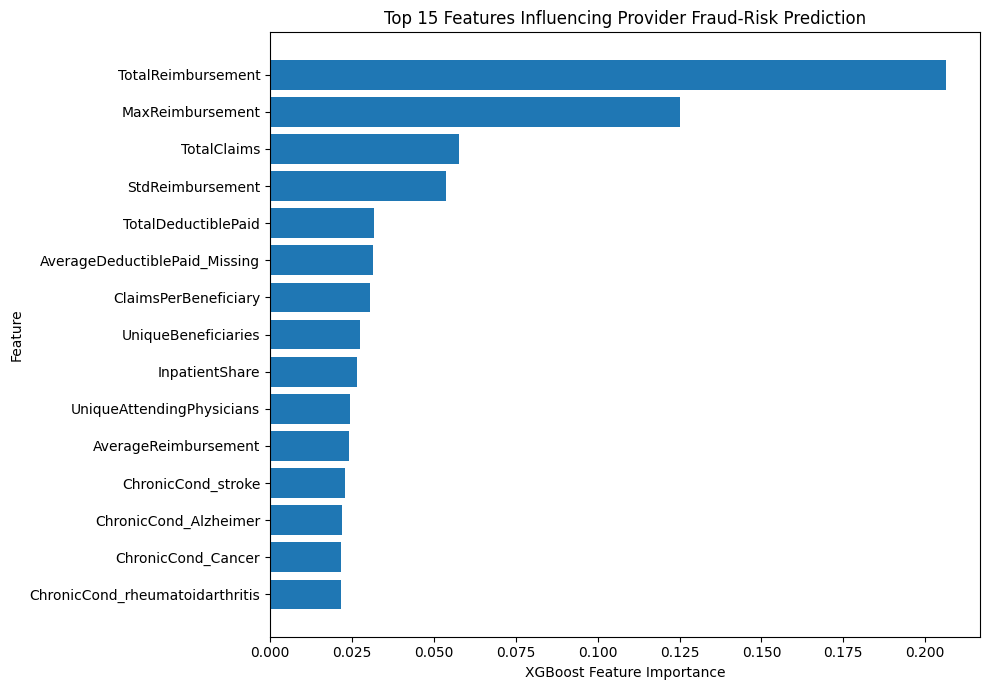

In [73]:
top15 = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top15["Feature"], top15["Importance"])
plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Provider Fraud-Risk Prediction")
plt.tight_layout()
plt.show()

In [74]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [75]:
print(type(final_xgb_model))
print("Number of features:", len(X_train.columns))
print("X_train shape:", X_train.shape)

<class 'xgboost.sklearn.XGBClassifier'>
Number of features: 30
X_train shape: (4328, 30)


In [76]:
explainer = shap.TreeExplainer(final_xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP shape:", shap_values.shape)
print("Test shape:", X_test.shape)

SHAP shape: (1082, 30)
Test shape: (1082, 30)


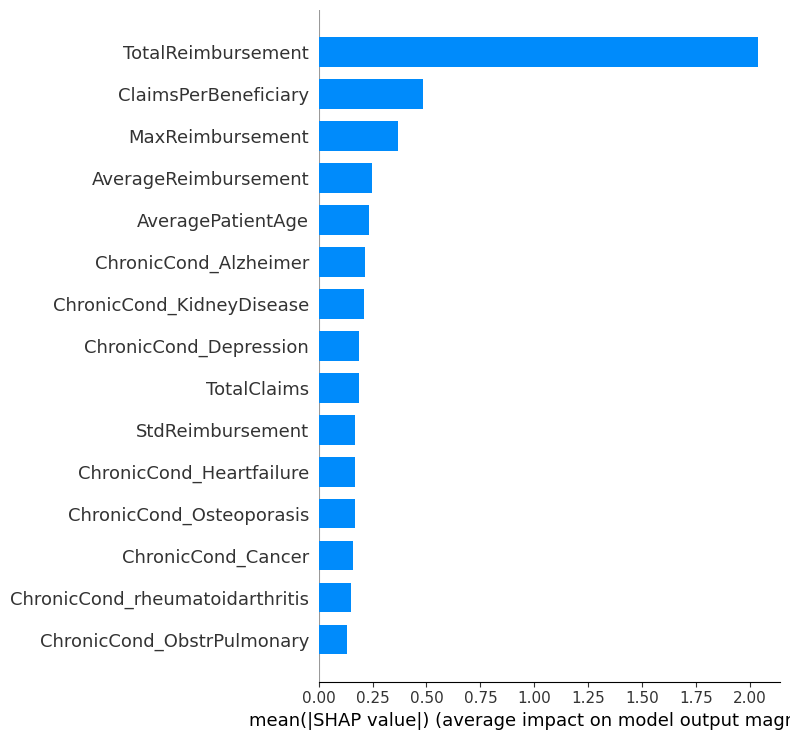

In [77]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15
)

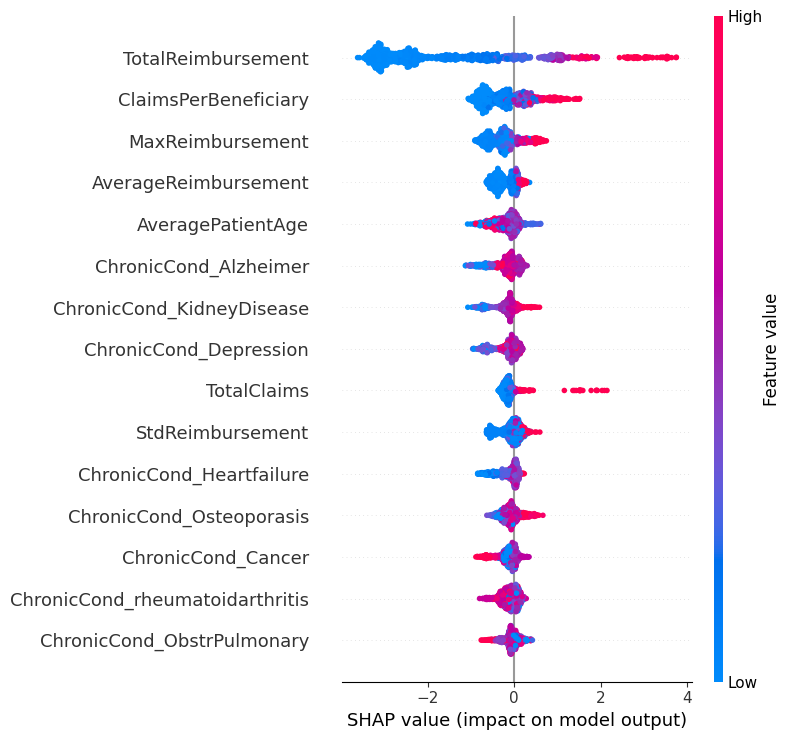

In [78]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

In [79]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, test_proba)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.7203


In [80]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np

# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

# Keep the test set completely untouched
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

# Stratified CV preserves fraud/non-fraud ratio
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Base XGBoost model
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Parameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7, 10],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "scale_pos_weight": [1, 1.5, 2, 3, 4]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

print("Starting hyperparameter search...")

random_search.fit(X_train, y_train)

print("\nTUNING COMPLETE")
print("=" * 60)

print("\nBest PR-AUC CV score:")
print(random_search.best_score_)

print("\nBest parameters:")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")

Training data: (4328, 30)
Test data: (1082, 30)
Starting hyperparameter search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

TUNING COMPLETE

Best PR-AUC CV score:
0.6825115057192173

Best parameters:
subsample: 0.8
scale_pos_weight: 1.5
reg_lambda: 0.5
reg_alpha: 0
n_estimators: 400
min_child_weight: 5
max_depth: 4
learning_rate: 0.01
gamma: 0.1
colsample_bytree: 0.8


In [81]:
# ============================================================
# BEST MODEL
# ============================================================

best_model = random_search.best_estimator_

print("Best model:")
print(best_model)

Best model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Best model from RandomizedSearchCV
tuned_model = random_search.best_estimator_

# Predict probabilities on the untouched test set
test_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("TUNED MODEL - TEST PERFORMANCE")
print("=" * 50)

print("ROC-AUC :", roc_auc_score(y_test, test_proba_tuned))
print("PR-AUC  :", average_precision_score(y_test, test_proba_tuned))

TUNED MODEL - TEST PERFORMANCE
ROC-AUC : 0.9574590486571594
PR-AUC  : 0.7508602911942631


In [83]:
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    pred = (test_proba_tuned >= threshold).astype(int)
    
    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Accuracy": accuracy_score(y_test, pred)
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

,Threshold,Precision,Recall,F1,Accuracy
0,0.10,0.353160,0.940594,0.513514,0.833641
1,0.15,0.413333,0.920792,0.570552,0.870610
2,0.20,0.460733,0.871287,0.602740,0.892791
3,0.25,0.505952,0.841584,0.631970,0.908503
4,0.30,0.543046,0.811881,0.650794,0.918669
5,0.35,0.571429,0.792079,0.663900,0.925139
6,0.40,0.600000,0.712871,0.651584,0.928835
7,0.45,0.650943,0.683168,0.666667,0.936229
8,0.50,0.703297,0.633663,0.666667,0.940850
9,0.55,0.740741,0.594059,0.659341,0.942699


In [84]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Best hyperparameters found by RandomizedSearchCV
best_model = random_search.best_estimator_

# 5-fold stratified CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store out-of-fold probabilities
oof_proba = np.zeros(len(X_train))

print("Generating out-of-fold predictions...")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train), 1
):
    
    # Fresh copy of the tuned model
    fold_model = clone(best_model)
    
    # Train only on this fold's training portion
    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )
    
    # Predict probabilities on unseen validation portion
    oof_proba[val_idx] = fold_model.predict_proba(
        X_train.iloc[val_idx]
    )[:, 1]
    
    print(f"Fold {fold} complete")

print("\nOOF predictions generated.")
print("OOF shape:", oof_proba.shape)

Generating out-of-fold predictions...
Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

OOF predictions generated.
OOF shape: (4328,)


In [85]:
thresholds = np.arange(0.01, 1.00, 0.01)

threshold_results = []

for threshold in thresholds:
    
    oof_pred = (oof_proba >= threshold).astype(int)
    
    precision = precision_score(
        y_train,
        oof_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_train,
        oof_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_train,
        oof_pred,
        zero_division=0
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.01,0.136944,0.980247,0.240315
1,0.02,0.213745,0.975309,0.350644
2,0.03,0.236408,0.955556,0.379040
3,0.04,0.255177,0.943210,0.401682
4,0.05,0.272532,0.940741,0.422629
...,...,...,...,...
94,0.95,0.000000,0.000000,0.000000
95,0.96,0.000000,0.000000,0.000000
96,0.97,0.000000,0.000000,0.000000
97,0.98,0.000000,0.000000,0.000000


In [86]:
# Require at least 80% recall
valid_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.80
].copy()

# Select threshold with highest precision
best_threshold_row = valid_thresholds.loc[
    valid_thresholds["Precision"].idxmax()
]

FINAL_THRESHOLD = best_threshold_row["Threshold"]

print("THRESHOLD SELECTION")
print("=" * 50)

print(f"Selected threshold : {FINAL_THRESHOLD:.2f}")
print(f"OOF Precision      : {best_threshold_row['Precision']:.4f}")
print(f"OOF Recall         : {best_threshold_row['Recall']:.4f}")
print(f"OOF F1             : {best_threshold_row['F1']:.4f}")

THRESHOLD SELECTION
Selected threshold : 0.23
OOF Precision      : 0.4731
OOF Recall         : 0.8025
OOF F1             : 0.5952


In [87]:
# Final tuned model trained on ALL training data
final_model = clone(best_model)

final_model.fit(
    X_train,
    y_train
)

# Test probabilities
test_proba_final = final_model.predict_proba(
    X_test
)[:, 1]

# Final classification using locked threshold
y_pred_final = (
    test_proba_final >= FINAL_THRESHOLD
).astype(int)

print("FINAL MODEL TEST RESULTS")
print("=" * 50)
print(f"Threshold : {FINAL_THRESHOLD:.2f}")

FINAL MODEL TEST RESULTS
Threshold : 0.23


In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Test probabilities from FINAL model
test_proba_final = final_model.predict_proba(X_test)[:, 1]

# Locked threshold
FINAL_THRESHOLD = 0.23

y_pred_final = (test_proba_final >= FINAL_THRESHOLD).astype(int)

print("=" * 60)
print("FINAL LOCKED-THRESHOLD TEST PERFORMANCE")
print("=" * 60)

print(f"Threshold : {FINAL_THRESHOLD:.2f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, test_proba_final):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, test_proba_final):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_final):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

FINAL LOCKED-THRESHOLD TEST PERFORMANCE
Threshold : 0.23
ROC-AUC   : 0.9575
PR-AUC    : 0.7509
Accuracy  : 0.9002
Precision : 0.4804
Recall    : 0.8515
F1        : 0.6143

Confusion Matrix:
[[888  93]
 [ 15  86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       981
           1       0.48      0.85      0.61       101

    accuracy                           0.90      1082
   macro avg       0.73      0.88      0.78      1082
weighted avg       0.94      0.90      0.91      1082



PROBABILITY CALIBRATION
Brier Score: 0.0438

Calibration bins:
Predicted: 0.006 | Actual: 0.000
Predicted: 0.008 | Actual: 0.000
Predicted: 0.009 | Actual: 0.000
Predicted: 0.010 | Actual: 0.000
Predicted: 0.012 | Actual: 0.000
Predicted: 0.020 | Actual: 0.000
Predicted: 0.048 | Actual: 0.046
Predicted: 0.104 | Actual: 0.037
Predicted: 0.278 | Actual: 0.213
Predicted: 0.702 | Actual: 0.633


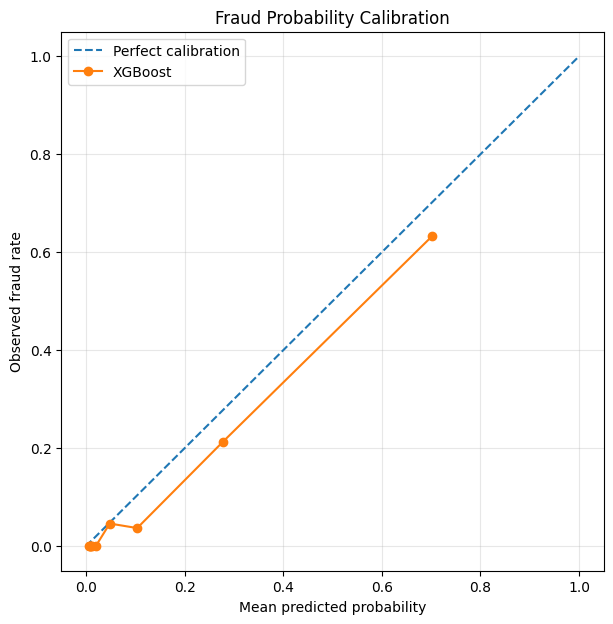

In [89]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Test-set predicted probabilities from the locked model
test_proba_final = final_model.predict_proba(X_test)[:, 1]

# Brier score
brier = brier_score_loss(y_test, test_proba_final)

print("=" * 60)
print("PROBABILITY CALIBRATION")
print("=" * 60)

print(f"Brier Score: {brier:.4f}")

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    test_proba_final,
    n_bins=10,
    strategy="quantile"
)

print("\nCalibration bins:")
for predicted, actual in zip(prob_pred, prob_true):
    print(
        f"Predicted: {predicted:.3f} | "
        f"Actual: {actual:.3f}"
    )

# Plot
plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraud rate")
plt.title("Fraud Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [90]:
import joblib
import json
import os

# Create model directory
os.makedirs("/kaggle/working/fraud_model", exist_ok=True)

# Save trained model
joblib.dump(
    final_model,
    "/kaggle/working/fraud_model/xgboost_fraud_model.pkl"
)

# Save feature names
feature_info = {
    "features": list(X_train.columns),
    "n_features": len(X_train.columns)
}

with open("/kaggle/working/fraud_model/features.json", "w") as f:
    json.dump(feature_info, f, indent=4)

# Save threshold
model_config = {
    "threshold": float(FINAL_THRESHOLD),
    "model_type": "XGBoost",
    "threshold_selection": "OOF predictions with recall constraint",
    "optimization_metric": "PR-AUC"
}

with open("/kaggle/working/fraud_model/config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("MODEL ARTIFACTS SAVED")
print("======================")
print("Model      :", "/kaggle/working/fraud_model/xgboost_fraud_model.pkl")
print("Features   :", "/kaggle/working/fraud_model/features.json")
print("Config     :", "/kaggle/working/fraud_model/config.json")
print("Threshold  :", FINAL_THRESHOLD)

MODEL ARTIFACTS SAVED
Model      : /kaggle/working/fraud_model/xgboost_fraud_model.pkl
Features   : /kaggle/working/fraud_model/features.json
Config     : /kaggle/working/fraud_model/config.json
Threshold  : 0.23


In [91]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [92]:
# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (1082, 30)


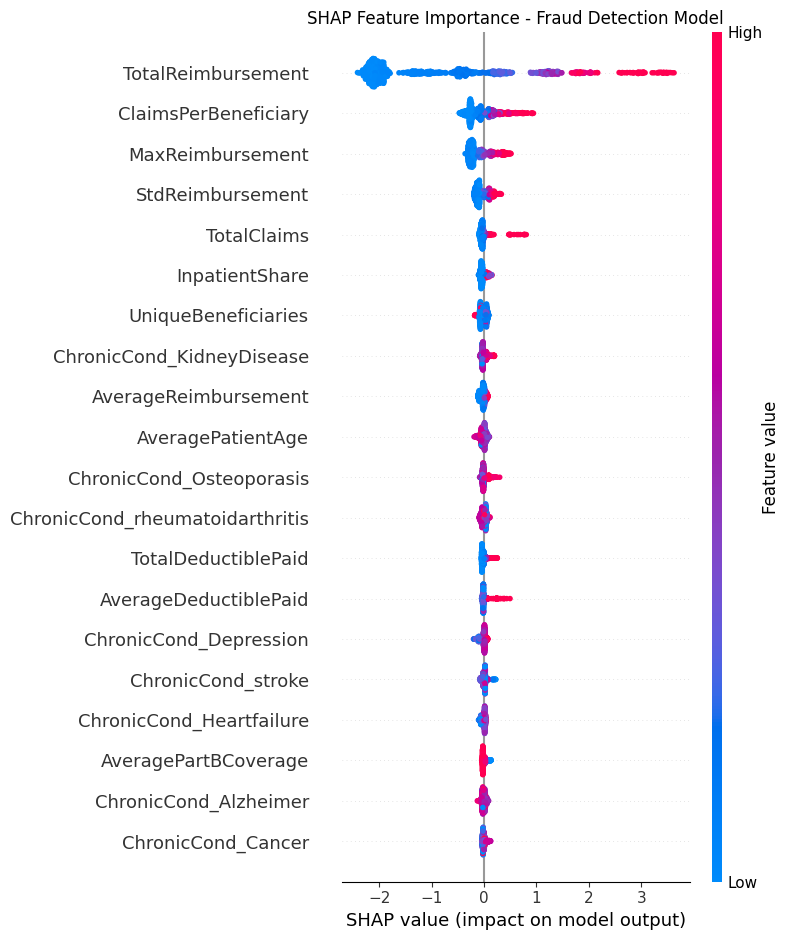

In [93]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance - Fraud Detection Model")
plt.tight_layout()
plt.show()

In [94]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "MeanAbsSHAP",
    ascending=False
).reset_index(drop=True)

print("TOP 20 FEATURES")
print("=" * 60)

display(shap_importance.head(20))

TOP 20 FEATURES


,Feature,MeanAbsSHAP
0,TotalReimbursement,1.616392
1,ClaimsPerBeneficiary,0.221938
2,MaxReimbursement,0.210322
3,StdReimbursement,0.113363
4,TotalClaims,0.052242
5,InpatientShare,0.052026
6,UniqueBeneficiaries,0.046420
7,ChronicCond_KidneyDisease,0.038722
8,AverageReimbursement,0.036338
9,AveragePatientAge,0.036039


In [95]:
def explain_provider(index, X_data=X_test):
    
    row = X_data.iloc[[index]]
    
    # Prediction
    probability = final_model.predict_proba(row)[0, 1]
    
    # SHAP
    row_shap = explainer.shap_values(row)[0]
    
    explanation = pd.DataFrame({
        "Feature": row.columns,
        "Value": row.iloc[0].values,
        "SHAP": row_shap
    })
    
    # Features pushing toward fraud
    fraud_factors = explanation[
        explanation["SHAP"] > 0
    ].sort_values(
        "SHAP",
        ascending=False
    )
    
    # Features pushing toward legitimate
    legitimate_factors = explanation[
        explanation["SHAP"] < 0
    ].sort_values(
        "SHAP",
        ascending=True
    )
    
    return probability, fraud_factors, legitimate_factors

In [96]:
probability, fraud_factors, legitimate_factors = explain_provider(0)

print("Fraud Probability:", round(probability, 4))
print("Decision:", "FRAUD FLAG" if probability >= FINAL_THRESHOLD else "NOT FLAGGED")

print("\nTOP FRAUD CONTRIBUTING FEATURES")
display(fraud_factors.head(10))

print("\nTOP LEGITIMATE CONTRIBUTING FEATURES")
display(legitimate_factors.head(10))

Fraud Probability: 0.1478
Decision: NOT FLAGGED

TOP FRAUD CONTRIBUTING FEATURES


,Feature,Value,SHAP
2,TotalReimbursement,158670.000000,0.927344
0,TotalClaims,587.000000,0.146401
6,TotalDeductiblePaid,1010.000000,0.063923
13,AveragePatientAge,74.123077,0.034259
16,AveragePartBCoverage,11.942308,0.024622
18,ChronicCond_Heartfailure,0.565385,0.020598
22,ChronicCond_Depression,0.436538,0.012466
9,UniqueOperatingPhysicians,3.000000,0.007704
7,AverageDeductiblePaid,1.720613,0.004791
23,ChronicCond_Diabetes,0.705769,0.003580



TOP LEGITIMATE CONTRIBUTING FEATURES


,Feature,Value,SHAP
4,MaxReimbursement,3300.000000,-0.229399
11,ClaimsPerBeneficiary,1.128846,-0.183913
5,StdReimbursement,532.357345,-0.139984
1,UniqueBeneficiaries,520.000000,-0.139173
19,ChronicCond_KidneyDisease,0.378846,-0.073977
12,InpatientShare,0.000000,-0.064357
26,ChronicCond_rheumatoidarthritis,0.296154,-0.064284
25,ChronicCond_Osteoporasis,0.288462,-0.057537
3,AverageReimbursement,270.306644,-0.047074
24,ChronicCond_IschemicHeart,0.753846,-0.021534


In [97]:
def generate_provider_explanation(index):
    
    row = X_test.iloc[[index]]
    
    probability = float(
        final_model.predict_proba(row)[0, 1]
    )
    
    shap_row = explainer.shap_values(row)[0]
    
    explanation = pd.DataFrame({
        "feature": row.columns,
        "value": row.iloc[0].values,
        "shap": shap_row
    })
    
    positive = explanation[
        explanation["shap"] > 0
    ].sort_values("shap", ascending=False)
    
    negative = explanation[
        explanation["shap"] < 0
    ].sort_values("shap")
    
    result = {
        "fraud_probability": round(probability, 4),
        "threshold": float(FINAL_THRESHOLD),
        "decision": (
            "FRAUD_FLAG"
            if probability >= FINAL_THRESHOLD
            else "NOT_FLAGGED"
        ),
        "top_fraud_factors": positive.head(5).to_dict("records"),
        "top_legitimate_factors": negative.head(5).to_dict("records")
    }
    
    return result

In [98]:
result = generate_provider_explanation(0)

result

{'fraud_probability': 0.1478,
 'threshold': 0.23,
 'decision': 'NOT_FLAGGED',
 'top_fraud_factors': [{'feature': 'TotalReimbursement',
   'value': 158670.0,
   'shap': 0.9273443818092346},
  {'feature': 'TotalClaims', 'value': 587.0, 'shap': 0.14640089869499207},
  {'feature': 'TotalDeductiblePaid',
   'value': 1010.0,
   'shap': 0.06392276287078857},
  {'feature': 'AveragePatientAge',
   'value': 74.12307692307692,
   'shap': 0.034258730709552765},
  {'feature': 'AveragePartBCoverage',
   'value': 11.942307692307692,
   'shap': 0.02462197095155716}],
 'top_legitimate_factors': [{'feature': 'MaxReimbursement',
   'value': 3300.0,
   'shap': -0.2293993979692459},
  {'feature': 'ClaimsPerBeneficiary',
   'value': 1.1288461538461538,
   'shap': -0.18391291797161102},
  {'feature': 'StdReimbursement',
   'value': 532.3573449001086,
   'shap': -0.13998408615589142},
  {'feature': 'UniqueBeneficiaries',
   'value': 520.0,
   'shap': -0.13917268812656403},
  {'feature': 'ChronicCond_KidneyDis

In [100]:
print(provider_data.shape)

(5410, 32)


In [101]:
# Export the complete aggregated provider-level dataset

provider_data.to_csv(
    "/kaggle/working/provider_data_aggregated.csv",
    index=False
)

print("Exported successfully!")
print("Shape:", provider_data.shape)
print("File: /kaggle/working/provider_data_aggregated.csv")

Exported successfully!
Shape: (5410, 32)
File: /kaggle/working/provider_data_aggregated.csv
